<a href="https://colab.research.google.com/github/aayush8644/data-structure-and-communicationlab/blob/main/dsa29_multivariatet__inear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

data=load_diabetes()
X=data.data
y=data.target

print("X space:",X.shape)


X space: (442, 10)


In [ ]:
#train test split and feature standarization
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

#add intercept column of 1s
x_train_b=np.hstack((np.ones((x_train.shape[0],1)),x_train))
x_test_b=np.hstack((np.ones((x_test.shape[0],1)),x_test))
print("X_train_b space:",x_train_b.shape)

X_train_b space: (353, 11)


In [ ]:
#step 3:implement batch gradient descent
def gradient_descent(x,y,alpha=0.3,n_iter=1000):
    m,n=x.shape
    beta=np.zeros(n)
    cost_history=[]
    for i in range(n_iter):
      y_pred=x @ beta
      error=y_pred - y
      gradient=(1/m)*(x.T @ error)
      beta-= alpha * gradient
      cost_history.append((1/(2*m))*np.sum(error**2))
    return beta,cost_history

beta_gd,cost_history = gradient_descent(x_train_b,y_train,alpha=0.3,n_iter=1000)
print("learned coefficient(incl.intercept):")
print(beta_gd)

learned coefficient(incl.intercept):
[153.73654391   1.76789427 -11.50636393  25.65707278  16.81279652
 -41.85347223  22.61078626   6.5319946   12.78233529  34.16522877
   2.3701572 ]


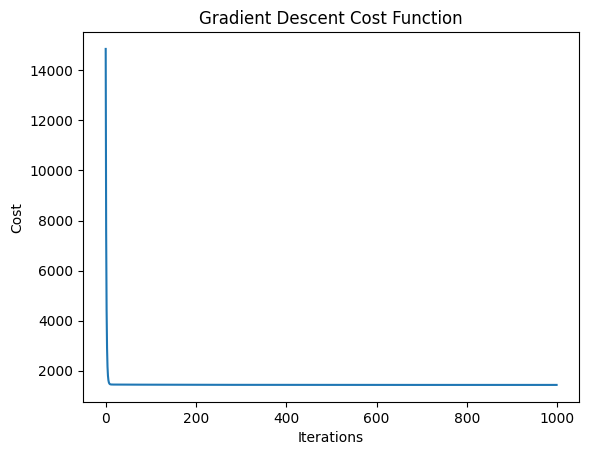

In [ ]:
#plot cost function
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent Cost Function")
plt.show()

In [ ]:
#solve via a noraml equation
beta_ne=np.linalg.pinv(x_train_b.T @ x_train_b) @ x_train_b.T @ y_train
print("learned coefficient(incl.intercept):")
print(beta_ne)


learned coefficient(incl.intercept):
[153.73654391   1.75375799 -11.51180908  25.60712144  16.82887167
 -44.44885564  24.64095356   7.67697768  13.1387839   35.16119521
   2.35136365]


In [ ]:
#step 6:Evaluate both model on the test set
def evaluate(y_true,y_pred,label):
  mse=np.mean((y_true-y_pred)**2)
  rmse=np.sqrt(mse)
  mae=np.mean(np.abs(y_true-y_pred))
  ss_res=np.sum((y_true-y_pred)**2)
  ss_tot=np.sum((y_true-np.mean(y_true))**2)
  r2=1-(ss_res/ss_tot)
  return{'model':label,'mse':mse,'rmse':rmse,'mae':mae,'r2':r2}

y_pred_gd=x_test_b @ beta_gd
y_pred_ne=x_test_b @ beta_ne

results=pd.DataFrame([evaluate(y_test,y_pred_gd,'Gradient Descent'),
                      evaluate(y_test,y_pred_ne,'Normal Equation')])
print(results)

              model          mse       rmse        mae        r2
0  Gradient Descent  2898.126946  53.834254  42.799285  0.452993
1   Normal Equation  2900.193628  53.853446  42.794095  0.452603
